# Hill's Pet Nutrition — Media Mix Model & Saturation Analysis
### Group 2: Media Mix Efficiency & Attribution
**Business Question:** What is the actual business impact of TV vs Programmatic advertising on sales, and how should budget be reallocated?
Built on GRANULAR datasets: retailer, tv_publisher, programmatic, mapping, socio_demo

In [2]:
# At the top of your notebook, run this cell first:

# from google.colab import files
# uploaded = files.upload()

### MMM - Marketing Mix Model

### ROAS - Return on Ad Spend

## 0. IMPORTS & CONFIG

In [4]:
import gc, os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.optimize import curve_fit
import statsmodels.api as sm
warnings.filterwarnings("ignore")

os.makedirs("outputs", exist_ok=True)


In [10]:
# ── File paths (Google Colab: upload files or mount Drive) ────────────────────
# If using Drive:
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_DIR = "/content/drive/MyDrive/hills_data/"

DATA_DIR    = "/content/"                                 # ← change if needed
RETAILER    = "/content/retailer.csv"
TV          = "/content/tv_publisher.csv"
PROG        = "/content/programmatic_publisher.csv"
MAPPING     = "/content/mapping_transac_publisher_tv.csv"
SOCIO       = "/content/socio_demo.csv"


In [11]:

# Brand palette

TV_COL   = "#003087"
PROG_COL = "#C8102E"
BASE_COL = "#6D6E71"
ACC_COL  = "#F0A500"
GREEN    = "#22C55E"
DARK_BG  = "#0D1117"
CARD_BG  = "#161B22"
TEXT     = "#E6EDF3"
MUTED    = "#8B949E"

plt.rcParams.update({
    "figure.facecolor": DARK_BG,  "axes.facecolor":   CARD_BG,
    "axes.edgecolor":   "#30363D","axes.labelcolor":  TEXT,
    "xtick.color":      MUTED,    "ytick.color":      MUTED,
    "text.color":       TEXT,     "grid.color":       "#21262D",
    "grid.linestyle":   "--",     "grid.alpha":       0.6,
    "axes.titlesize":   12,       "axes.labelsize":   10,
})





##  STEP 1 · CHUNK-READ & AGGREGATE  


```
(no full tables in RAM)
```



In [13]:
print("=" * 65)
print("STEP 1 — Chunk-reading large files …")
print("=" * 65)

CHUNK = 30_000

# 1A. RETAILER

retailer_weekly  = {}   # {week_str: {sales, orders, buyers_set}}
retailer_cust    = set()  # all unique customer_ids (for counting)
retailer_buyers  = set()  # customers who made at least 1 purchase

for chunk in pd.read_csv(
        RETAILER,
        usecols=["customer_id", "timestamp_utc", "event_name", "sales"],
        parse_dates=["timestamp_utc"],
        chunksize=CHUNK, low_memory=False):

    chunk.columns = chunk.columns.str.strip().str.lower()
    chunk["timestamp_utc"] = pd.to_datetime(chunk["timestamp_utc"],
                                             utc=True, errors="coerce")
    chunk.dropna(subset=["timestamp_utc","customer_id"], inplace=True)
    chunk["week"] = chunk["timestamp_utc"].dt.to_period("W").astype(str)
    chunk["sales"] = pd.to_numeric(chunk["sales"], errors="coerce").fillna(0)

    # All customers (for reach calc)
    retailer_cust.update(chunk["customer_id"].unique())

    # Purchase events only
    is_purchase = chunk["event_name"].str.lower().str.contains(
        "purchase|order|buy|transac|add_to_cart", na=False)
    # If no event matches, treat rows with sales>0 as purchases
    if is_purchase.sum() == 0:
        is_purchase = chunk["sales"] > 0

    purch = chunk[is_purchase]
    retailer_buyers.update(purch["customer_id"].unique())

    for week, grp in purch.groupby("week"):
        if week not in retailer_weekly:
            retailer_weekly[week] = {"sales": 0, "orders": 0, "buyers": set()}
        retailer_weekly[week]["sales"]  += grp["sales"].sum()
        retailer_weekly[week]["orders"] += len(grp)
        retailer_weekly[week]["buyers"].update(grp["customer_id"].unique())

    del chunk; gc.collect()

# Convert weekly dict -> DataFrame
rows = []
for week, v in sorted(retailer_weekly.items()):
    rows.append({"week": week, "sales": v["sales"],
                 "orders": v["orders"], "unique_buyers": len(v["buyers"])})
weekly_sales = pd.DataFrame(rows).sort_values("week").reset_index(drop=True)

total_sales  = weekly_sales["sales"].sum()
total_orders = weekly_sales["orders"].sum()
n_buyers     = len(retailer_buyers)
n_all_cust   = len(retailer_cust)
avg_basket   = total_sales / total_orders if total_orders > 0 else 0

print(f"  Retailer → {len(weekly_sales)} weeks | "
      f"Total sales: ${total_sales:,.2f} | "
      f"Avg basket: ${avg_basket:.2f} | "
      f"Buyers: {n_buyers:,}")
del retailer_cust; gc.collect()

STEP 1 — Chunk-reading large files …
  Retailer → 26 weeks | Total sales: $62,427,949.18 | Avg basket: $43.37 | Buyers: 502,026


0

In [15]:
# 1B. TV PUBLISHER

tv_weekly       = {}
tv_devices_all  = set()

for chunk in pd.read_csv(
        TV,
        usecols=["device_id", "timestamp_utc", "cost_milli_cent"],
        parse_dates=["timestamp_utc"],
        chunksize=CHUNK, low_memory=False):

    chunk.columns = chunk.columns.str.strip().str.lower()
    chunk["timestamp_utc"] = pd.to_datetime(chunk["timestamp_utc"],
                                             utc=True, errors="coerce")
    chunk.dropna(subset=["timestamp_utc","device_id"], inplace=True)
    chunk["cost_usd"] = pd.to_numeric(chunk["cost_milli_cent"],
                                       errors="coerce").fillna(0) / 100_000
    chunk["week"] = chunk["timestamp_utc"].dt.to_period("W").astype(str)

    tv_devices_all.update(chunk["device_id"].unique())

    for week, grp in chunk.groupby("week"):
        if week not in tv_weekly:
            tv_weekly[week] = {"tv_spend": 0, "tv_imp": 0}
        tv_weekly[week]["tv_spend"] += grp["cost_usd"].sum()
        tv_weekly[week]["tv_imp"]   += len(grp)

    del chunk; gc.collect()

rows = []
for week, v in sorted(tv_weekly.items()):
    rows.append({"week": week, **v})
weekly_tv = pd.DataFrame(rows).sort_values("week").reset_index(drop=True)
total_tv_spend = weekly_tv["tv_spend"].sum()
print(f"  TV      → {len(weekly_tv)} weeks | "
      f"Total spend: ${total_tv_spend:,.2f} | "
      f"Unique devices: {len(tv_devices_all):,}")


  TV      → 17 weeks | Total spend: $135,510.61 | Unique devices: 2,065,539


In [16]:
# 1C. PROGRAMMATIC PUBLISHER

prog_weekly     = {}
prog_users_all  = set()
prog_freq       = {}      # {dsp_id: impression_count} → for capping analysis

for chunk in pd.read_csv(
        PROG,
        usecols=["dsp_id", "timestamp_utc", "campaign_name",
                 "device_type", "cost_milli_cent"],
        parse_dates=["timestamp_utc"],
        chunksize=CHUNK, low_memory=False):

    chunk.columns = chunk.columns.str.strip().str.lower()
    chunk["timestamp_utc"] = pd.to_datetime(chunk["timestamp_utc"],
                                             utc=True, errors="coerce")
    chunk.dropna(subset=["timestamp_utc","dsp_id"], inplace=True)
    chunk["cost_usd"] = pd.to_numeric(chunk["cost_milli_cent"],
                                       errors="coerce").fillna(0) / 100_000
    chunk["week"] = chunk["timestamp_utc"].dt.to_period("W").astype(str)

    prog_users_all.update(chunk["dsp_id"].unique())

    # Frequency count per user
    for dsp_id, cnt in chunk["dsp_id"].value_counts().items():
        prog_freq[dsp_id] = prog_freq.get(dsp_id, 0) + cnt

    for week, grp in chunk.groupby("week"):
        if week not in prog_weekly:
            prog_weekly[week] = {"prog_spend": 0, "prog_imp": 0}
        prog_weekly[week]["prog_spend"] += grp["cost_usd"].sum()
        prog_weekly[week]["prog_imp"]   += len(grp)

    del chunk; gc.collect()

rows = []
for week, v in sorted(prog_weekly.items()):
    rows.append({"week": week, **v})
weekly_prog = pd.DataFrame(rows).sort_values("week").reset_index(drop=True)
total_prog_spend = weekly_prog["prog_spend"].sum()
print(f"  Prog    → {len(weekly_prog)} weeks | "
      f"Total spend: ${total_prog_spend:,.2f} | "
      f"Unique users: {len(prog_users_all):,}")

  Prog    → 26 weeks | Total spend: $92,973.13 | Unique users: 5,101,025


In [17]:
# 1D. MAPPING  (small file – read in full)

# Columns: customer_id | dsp_id | device_id
mapping = pd.read_csv(MAPPING, low_memory=False)
mapping.columns = mapping.columns.str.strip().str.lower()
n_mapped = len(mapping)
exposed_both   = mapping[mapping["dsp_id"].notna() & mapping["device_id"].notna()]
exposed_tv_only  = mapping[mapping["device_id"].notna() & mapping["dsp_id"].isna()]
exposed_prog_only= mapping[mapping["dsp_id"].notna()    & mapping["device_id"].isna()]
print(f"  Mapping → {n_mapped:,} rows | "
      f"Both: {len(exposed_both):,} | "
      f"TV only: {len(exposed_tv_only):,} | "
      f"Prog only: {len(exposed_prog_only):,}")

  Mapping → 7,984,411 rows | Both: 7,825,710 | TV only: 0 | Prog only: 158,701


In [18]:
# 1E. SOCIO-DEMO  (small-ish – read in full)

# Columns: customer_id | breed | age | income
socio = pd.read_csv(SOCIO, low_memory=False)
socio.columns = socio.columns.str.strip().str.lower()
print(f"  Socio   → {len(socio):,} rows")
print(f"    breed dist : {socio['breed'].value_counts().to_dict()}")
print(f"    age   dist : {socio['age'].value_counts().head(4).to_dict()}")
print(f"    income dist: {socio['income'].value_counts().head(4).to_dict()}")


  Socio   → 1,354,584 rows
    breed dist : {'Purebred': 827017, 'Mixed-breed': 527567}
    age   dist : {'[65+[': 257005, '[25-35[': 244938, '[55-65[': 236190, '[45-55[': 230629}
    income dist: {'[120-200K$[': 297276, '[200K$+[': 284399, '[40-80K$[': 279708, '[80-120K$[': 279688}


In [19]:
# 1F. MERGE WEEKLY PANELS

weekly = (
    weekly_sales
    .merge(weekly_tv,   on="week", how="outer")
    .merge(weekly_prog, on="week", how="outer")
    .fillna(0)
    .sort_values("week")
    .reset_index(drop=True)
)
weekly["week_idx"] = range(len(weekly))
print(f"\n  Weekly panel: {len(weekly)} weeks")
print(weekly[["week","sales","tv_spend","prog_spend"]].head(4).to_string(index=False))


  Weekly panel: 26 weeks
                 week      sales  tv_spend  prog_spend
2024-01-01/2024-01-07 2464099.65       0.0 4452.676732
2024-01-08/2024-01-14 2414555.43       0.0 3915.250865
2024-01-15/2024-01-21 2334096.88       0.0 3789.817517
2024-01-22/2024-01-28 2409364.66       0.0 4151.946445


In [20]:
# MAPPING-LEVEL ATTRIBUTION COUNTS

# Use mapping to count buyers exposed to TV / Prog
buyer_set          = retailer_buyers          # set of customer_ids who bought
mapping_buyers_tv  = set(mapping.loc[mapping["device_id"].notna(), "customer_id"]) & buyer_set
mapping_buyers_prog= set(mapping.loc[mapping["dsp_id"].notna(),    "customer_id"]) & buyer_set
mapping_buyers_both= mapping_buyers_tv & mapping_buyers_prog
mapping_buyers_none= buyer_set - mapping_buyers_tv - mapping_buyers_prog

print(f"\n  Attribution:")
print(f"    Buyers exposed to TV         : {len(mapping_buyers_tv):,}")
print(f"    Buyers exposed to Prog       : {len(mapping_buyers_prog):,}")
print(f"    Buyers exposed to BOTH       : {len(mapping_buyers_both):,}")
print(f"    Buyers with NO ad exposure   : {len(mapping_buyers_none):,}")
del mapping; gc.collect()



  Attribution:
    Buyers exposed to TV         : 502,025
    Buyers exposed to Prog       : 502,026
    Buyers exposed to BOTH       : 502,025
    Buyers with NO ad exposure   : 0


0

## STEP 2 · S3 - **CORE MMM**  (adstock + OLS)




In [21]:
print("\n" + "=" * 65)
print("STEP 2 — S3: Media Mix Model [MMM]")
print("=" * 65)

# 2A. Adstock
def adstock(series, decay):
    """Geometric adstock: effective_spend[t] = spend[t] + decay*effective[t-1]"""
    out = np.zeros(len(series))
    arr = series.values
    for i, s in enumerate(arr):
        out[i] = s + (decay * out[i-1] if i > 0 else 0)
    return out

# TV -> long brand-recall decay (echoes many weeks)
# Programmatic -> fast digital decay
TV_DECAY   = 0.55
PROG_DECAY = 0.20

weekly["tv_adstock"]   = adstock(weekly["tv_spend"],   TV_DECAY)
weekly["prog_adstock"] = adstock(weekly["prog_spend"], PROG_DECAY)

print(f"  TV adstock   decay = {TV_DECAY}  "
      f"(~{round(1/(1-TV_DECAY))} week effective window)")
print(f"  Prog adstock decay = {PROG_DECAY}  "
      f"(~{round(1/(1-PROG_DECAY))} week effective window)")


STEP 2 — S3: Media Mix Model [MMM]
  TV adstock   decay = 0.55  (~2 week effective window)
  Prog adstock decay = 0.2  (~1 week effective window)


In [22]:
# 2B. OLS Regression

X = sm.add_constant(weekly[["tv_adstock", "prog_adstock"]])
y = weekly["sales"]
model = sm.OLS(y, X).fit()

print("\n  OLS Regression (Sales ~ baseline + TV_adstock + Prog_adstock)")
print(f"  R²  = {model.rsquared:.4f}")
print(f"  Adj R² = {model.rsquared_adj:.4f}")
print(f"  p-values → TV: {model.pvalues['tv_adstock']:.4f}  "
      f"Prog: {model.pvalues['prog_adstock']:.4f}")

weekly["sales_pred"]     = model.predict(X)
weekly["baseline_sales"] = model.params["const"]
weekly["tv_contrib"]     = model.params["tv_adstock"]   * weekly["tv_adstock"]
weekly["prog_contrib"]   = model.params["prog_adstock"] * weekly["prog_adstock"]


  OLS Regression (Sales ~ baseline + TV_adstock + Prog_adstock)
  R²  = 0.7469
  Adj R² = 0.7249
  p-values → TV: 0.5979  Prog: 0.0004


In [23]:
# 2C. ROAS

tv_incr    = weekly["tv_contrib"].sum()
prog_incr  = weekly["prog_contrib"].sum()
base_total = weekly["baseline_sales"].sum()
roas_tv    = tv_incr   / total_tv_spend   if total_tv_spend   > 0 else 0
roas_prog  = prog_incr / total_prog_spend if total_prog_spend > 0 else 0

tv_pct   = tv_incr   / total_sales * 100
prog_pct = prog_incr / total_sales * 100
base_pct = base_total/ total_sales * 100

print(f"\n  ── ROAS Summary ──")
print(f"  TV   → ${tv_incr:>10,.2f} incremental | "
      f"${total_tv_spend:>10,.2f} spend | ROAS = {roas_tv:.2f}×")
print(f"  Prog → ${prog_incr:>10,.2f} incremental | "
      f"${total_prog_spend:>10,.2f} spend | ROAS = {roas_prog:.2f}×")
print(f"\n  ── Sales Decomposition ──")
print(f"  Baseline : {base_pct:>5.1f}%  (${base_total:>12,.2f})")
print(f"  TV       : {tv_pct:>5.1f}%  (${tv_incr:>12,.2f})")
print(f"  Prog     : {prog_pct:>5.1f}%  (${prog_incr:>12,.2f})")



  ── ROAS Summary ──
  TV   → $-389,918.31 incremental | $135,510.61 spend | ROAS = -2.88×
  Prog → $11,839,039.17 incremental | $ 92,973.13 spend | ROAS = 127.34×

  ── Sales Decomposition ──
  Baseline :  81.7%  ($50,978,828.32)
  TV       :  -0.6%  ($ -389,918.31)
  Prog     :  19.0%  ($11,839,039.17)






## 2D. S3 CHARTS


  -> Generating S3 charts …


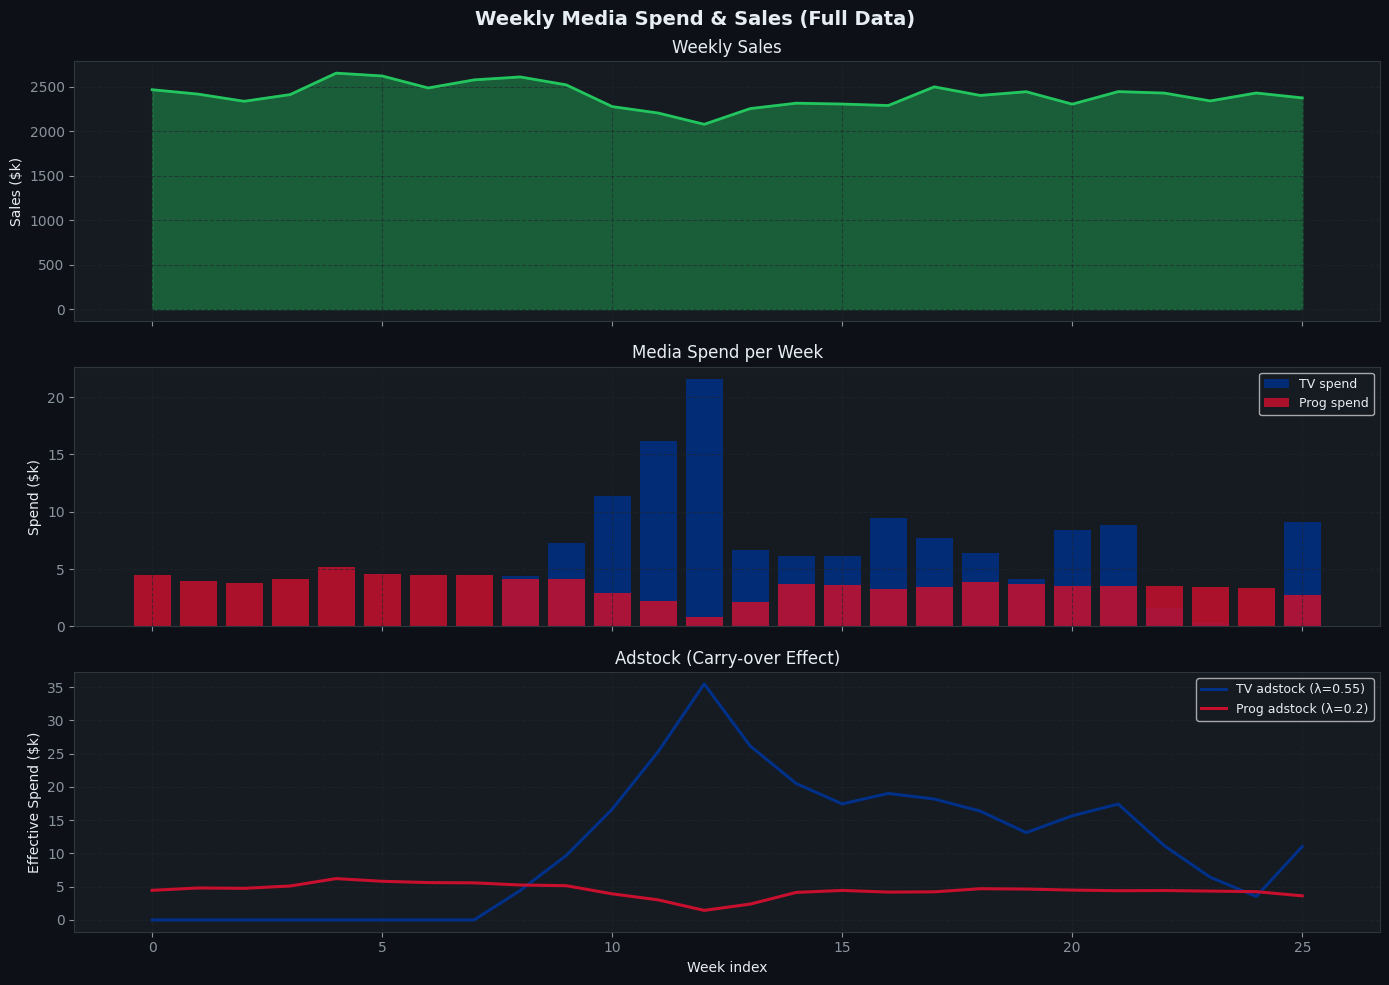

In [26]:
print("\n  -> Generating S3 charts …")
x = range(len(weekly))

# Chart S3-1: Weekly time series

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle("Weekly Media Spend & Sales (Full Data)",
             fontsize=14, color=TEXT, fontweight="bold")

axes[0].fill_between(x, weekly["sales"]/1e3, alpha=0.4, color=GREEN)
axes[0].plot(x, weekly["sales"]/1e3, color=GREEN, lw=2)
axes[0].set_ylabel("Sales ($k)"); axes[0].grid(True)
axes[0].set_title("Weekly Sales", color=TEXT)

axes[1].bar(x, weekly["tv_spend"]/1e3,   color=TV_COL,   alpha=0.85, label="TV spend")
axes[1].bar(x, weekly["prog_spend"]/1e3, color=PROG_COL, alpha=0.85, label="Prog spend", bottom=0)
axes[1].set_ylabel("Spend ($k)"); axes[1].legend(fontsize=9); axes[1].grid(True)
axes[1].set_title("Media Spend per Week", color=TEXT)

axes[2].plot(x, weekly["tv_adstock"]/1e3,   color=TV_COL,   lw=2.2,
             label=f"TV adstock (λ={TV_DECAY})")
axes[2].plot(x, weekly["prog_adstock"]/1e3, color=PROG_COL, lw=2.2,
             label=f"Prog adstock (λ={PROG_DECAY})")
axes[2].set_ylabel("Effective Spend ($k)"); axes[2].legend(fontsize=9); axes[2].grid(True)
axes[2].set_title("Adstock (Carry-over Effect)", color=TEXT)
axes[2].set_xlabel("Week index")

plt.tight_layout()




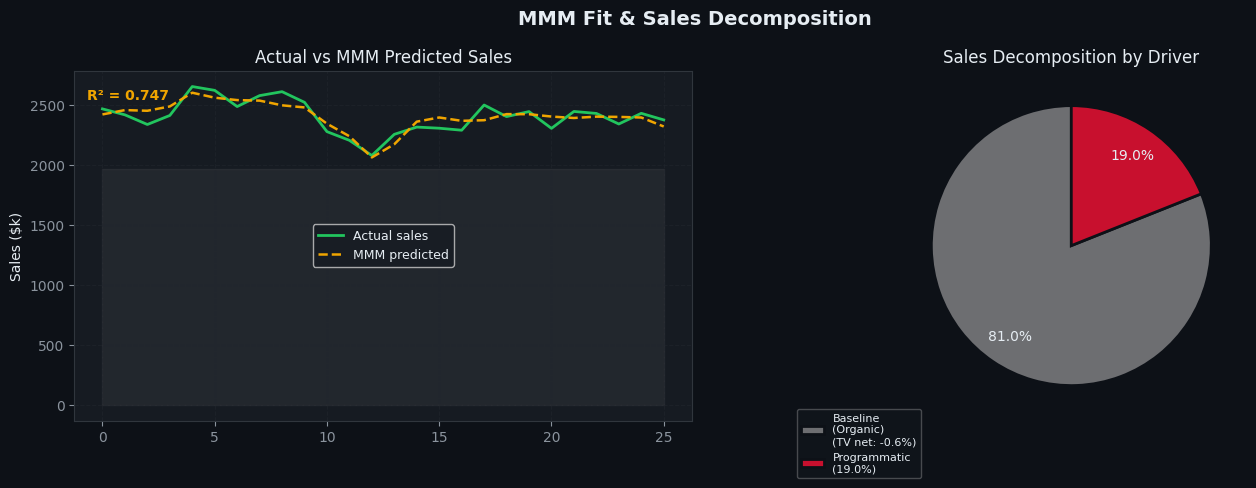

In [31]:
# Chart S3-2: Model fit + decomposition

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("MMM Fit & Sales Decomposition",
             fontsize=14, color=TEXT, fontweight="bold")

ax = axes[0]
ax.plot(x, weekly["sales"]/1e3,      color=GREEN,   lw=2,   label="Actual sales")
ax.plot(x, weekly["sales_pred"]/1e3, color=ACC_COL, lw=1.8, linestyle="--",
        label="MMM predicted")
ax.fill_between(x, weekly["baseline_sales"]/1e3, alpha=0.15, color=BASE_COL)
ax.set_title("Actual vs MMM Predicted Sales", color=TEXT)
ax.set_ylabel("Sales ($k)"); ax.legend(fontsize=9); ax.grid(True)
ax.text(0.02, 0.95, f"R² = {model.rsquared:.3f}", transform=ax.transAxes,
        color=ACC_COL, fontsize=10, fontweight="bold", va="top")

ax = axes[1]
# Dynamically build sizes, labels, and colors for the pie chart
pie_sizes  = []
pie_labels = []
pie_colors = []

# Handle baseline contribution, absorbing any negative TV contribution
adjusted_base_total = base_total + (tv_incr if tv_incr < 0 else 0)
if adjusted_base_total > 0:
    pie_sizes.append(adjusted_base_total)
    # Include TV impact in the baseline label if TV was negative
    if tv_incr < 0:
        pie_labels.append(f"Baseline\n(Organic)\n(TV net: {tv_pct:.1f}%)")
    else:
        pie_labels.append("Baseline\n(Organic)")
    pie_colors.append(BASE_COL)

# Handle TV contribution if positive
if tv_incr > 0:
    pie_sizes.append(tv_incr)
    pie_labels.append(f"TV\n({tv_pct:.1f}%)")
    pie_colors.append(TV_COL)

# Handle programmatic contribution
if prog_incr > 0:
    pie_sizes.append(prog_incr)
    pie_labels.append(f"Programmatic\n({prog_pct:.1f}%)")
    pie_colors.append(PROG_COL)

# Ensure there are values to plot, otherwise skip pie chart or handle
if not pie_sizes:
    ax.text(0.5, 0.5, "No positive contributions to display in pie chart.",
            horizontalalignment='center', verticalalignment='center',
            transform=ax.transAxes, color=TEXT, fontsize=10)
else:
    wedges, _, auts = ax.pie(
        pie_sizes, colors=pie_colors, autopct="%1.1f%%",
        startangle=90, pctdistance=0.78,
        wedgeprops=dict(edgecolor=DARK_BG, linewidth=2),
        textprops={"color": TEXT, "fontsize": 10})
    ax.legend(pie_labels, loc="lower left", fontsize=8, framealpha=0.3,
              bbox_to_anchor=(-0.3, -0.18))
    ax.set_title("Sales Decomposition by Driver", color=TEXT)
    ax.set_facecolor(DARK_BG)

plt.tight_layout()

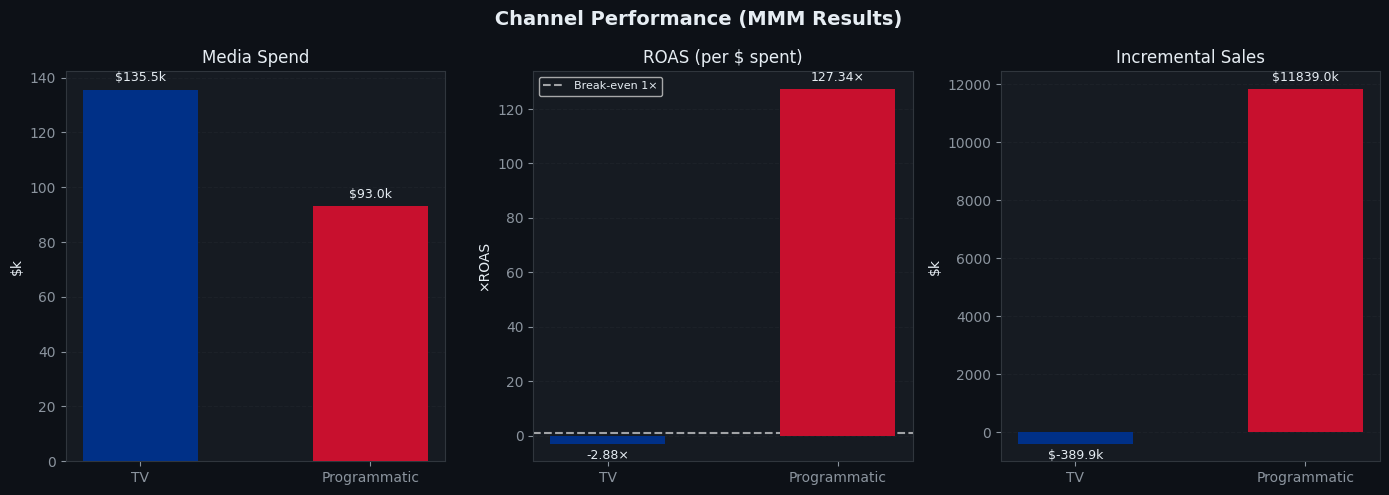

In [33]:
# Chart S3-3: ROAS bars

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle(" Channel Performance (MMM Results)",
             fontsize=14, color=TEXT, fontweight="bold")

chs   = ["TV", "Programmatic"]
clrs  = [TV_COL, PROG_COL]

ax = axes[0]
bars = ax.bar(chs, [total_tv_spend/1e3, total_prog_spend/1e3], color=clrs, width=0.5, zorder=3)
ax.bar_label(bars, fmt="$%.1fk", padding=4, color=TEXT, fontsize=9)
ax.set_title("Media Spend"); ax.set_ylabel("$k"); ax.grid(axis="y", zorder=0)

ax = axes[1]
bars = ax.bar(chs, [roas_tv, roas_prog], color=clrs, width=0.5, zorder=3)
ax.axhline(1.0, color="white", lw=1.5, ls="--", alpha=0.6, label="Break-even 1×")
ax.bar_label(bars, fmt="%.2f×", padding=4, color=TEXT, fontsize=9)
ax.set_title("ROAS (per $ spent)"); ax.set_ylabel("×ROAS")
ax.legend(fontsize=8); ax.grid(axis="y", zorder=0)

ax = axes[2]
bars = ax.bar(chs, [tv_incr/1e3, prog_incr/1e3], color=clrs, width=0.5, zorder=3)
ax.bar_label(bars, fmt="$%.1fk", padding=4, color=TEXT, fontsize=9)
ax.set_title("Incremental Sales"); ax.set_ylabel("$k"); ax.grid(axis="y", zorder=0)

plt.tight_layout()



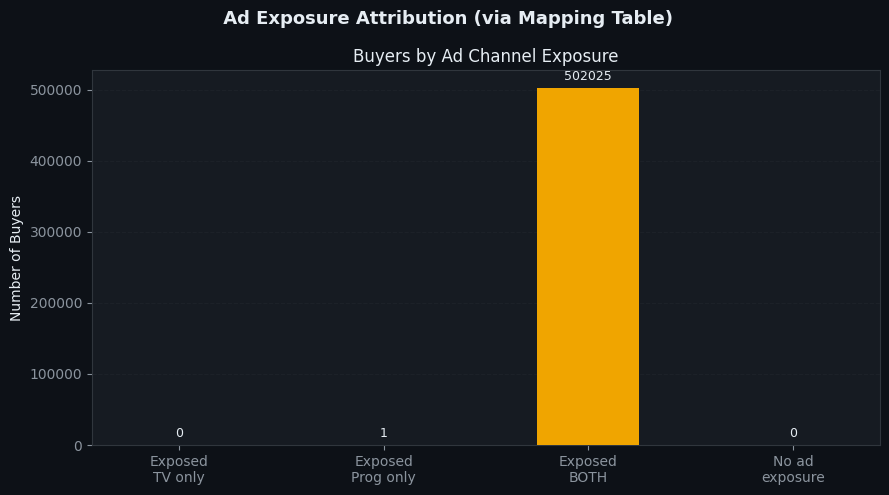

In [34]:
# Chart S3-4: Attribution exposure funnel

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle(" Ad Exposure Attribution (via Mapping Table)",
             fontsize=13, color=TEXT, fontweight="bold")

exp_labs  = ["Exposed\nTV only", "Exposed\nProg only",
             "Exposed\nBOTH", "No ad\nexposure"]
exp_vals  = [len(mapping_buyers_tv   - mapping_buyers_prog),
             len(mapping_buyers_prog - mapping_buyers_tv),
             len(mapping_buyers_both),
             len(mapping_buyers_none)]
exp_clrs  = [TV_COL, PROG_COL, ACC_COL, BASE_COL]
bars = ax.bar(exp_labs, exp_vals, color=exp_clrs, width=0.5, zorder=3)
ax.bar_label(bars, fmt="%d", padding=4, color=TEXT, fontsize=9)
ax.set_title("Buyers by Ad Channel Exposure", color=TEXT)
ax.set_ylabel("Number of Buyers"); ax.grid(axis="y", zorder=0)

plt.tight_layout()


## STEP 3 · S4 — SATURATION CURVES & DIMINISHING RETURNS

In [3]:
print("\n" + "=" * 65)
print("STEP 3 — S4: Saturation Curves")
print("=" * 65)


STEP 3 — S4: Saturation Curves


In [35]:
# 3A. Fit Hill saturation function to real weekly data

def hill(x, alpha, K, beta):
    x = np.clip(x, 1e-9, None)
    return beta * (x**alpha) / (K**alpha + x**alpha)

def fit_hill(x_col, y_col, label):
    x = weekly[x_col].values
    y = weekly[y_col].values
    mask = x > 0
    x_, y_ = x[mask], y[mask]
    p0 = [0.7, np.median(x_) if len(x_) else 1, np.max(y_) if len(y_) else 1]
    try:
        popt, _ = curve_fit(
            hill, x_, y_, p0=p0,
            bounds=([0.1, 1e-3, 0], [3.0, 1e12, 1e12]),
            maxfev=12000)
        alpha, K, beta = popt
        yp   = hill(x_, *popt)
        ss_r = np.sum((y_ - yp)**2)
        ss_t = np.sum((y_ - y_.mean())**2)
        r2   = 1 - ss_r/ss_t if ss_t > 0 else 0
        print(f"  [{label}] α={alpha:.3f}  K=${K:>10,.0f}  β=${beta:>10,.0f}  "
              f"fit R²={r2:.3f}")
        return alpha, K, beta
    except Exception as e:
        print(f"  [{label}] curve_fit failed ({e}). Using linear fallback.")
        b  = np.polyfit(x_, y_, 1)[0] if len(x_) > 1 else 1
        return 0.5, np.max(x_)*0.8, b * np.max(x_)

tv_a,   tv_K,   tv_b   = fit_hill("tv_adstock",   "tv_contrib",   "TV")
prog_a, prog_K, prog_b = fit_hill("prog_adstock", "prog_contrib", "Programmatic")

  [TV] curve_fit failed (Initial guess is outside of provided bounds). Using linear fallback.
  [Programmatic] α=1.000  K=$9,737,433,415  β=$999,751,622,371  fit R²=1.000


In [36]:
# 3B. Saturation curve over spend range

tv_range   = np.linspace(0, total_tv_spend * 2,   600)
prog_range = np.linspace(0, total_prog_spend * 2, 600)

tv_resp   = hill(tv_range,   tv_a,   tv_K,   tv_b)
prog_resp = hill(prog_range, prog_a, prog_K, prog_b)

In [37]:
# 3C. Marginal ROAS (derivative of Hill curve)

def marginal_roas(x_arr, alpha, K, beta):
    eps = np.maximum(x_arr * 0.005, 0.01)
    return (hill(x_arr+eps, alpha, K, beta) - hill(x_arr, alpha, K, beta)) / eps

tv_mroas   = marginal_roas(tv_range,   tv_a,   tv_K,   tv_b)
prog_mroas = marginal_roas(prog_range, prog_a, prog_K, prog_b)

def sat_point(spend_arr, mroas_arr, thr=1.0):
    idx = np.where(mroas_arr < thr)[0]
    return spend_arr[idx[0]] if len(idx) else None

tv_sat   = sat_point(tv_range,   tv_mroas)
prog_sat = sat_point(prog_range, prog_mroas)

cur_tv_m   = float(marginal_roas(np.array([total_tv_spend]),   tv_a,   tv_K,   tv_b))
cur_prog_m = float(marginal_roas(np.array([total_prog_spend]), prog_a, prog_K, prog_b))

print(f"\n  TV   saturation (mROAS=1×): "
      + (f"${tv_sat:,.0f}"   if tv_sat   else "beyond modelled range"))
print(f"  Prog saturation (mROAS=1×): "
      + (f"${prog_sat:,.0f}" if prog_sat else "beyond modelled range"))
print(f"  Current TV   spend: ${total_tv_spend:>10,.2f}  →  mROAS = {cur_tv_m:.3f}×")
print(f"  Current Prog spend: ${total_prog_spend:>10,.2f}  →  mROAS = {cur_prog_m:.3f}×")


  TV   saturation (mROAS=1×): beyond modelled range
  Prog saturation (mROAS=1×): beyond modelled range
  Current TV   spend: $135,510.61  →  mROAS = -0.038×
  Current Prog spend: $ 92,973.13  →  mROAS = 102.669×


In [38]:
# 3D. Frequency-capping analysis (programmatic only)

# prog_freq = {dsp_id: total_impressions}  built in Step 1C
freq_series = pd.Series(list(prog_freq.values()), name="impressions")
bins   = [0,1,2,3,5,10,15,20,25,35,50,1000]
labels = ["1","2","3","4-5","6-10","11-15","16-20","21-25","26-35","36-50","51+"]
freq_series = pd.cut(freq_series, bins=bins, labels=labels, right=True)
freq_dist   = freq_series.value_counts().sort_index().reset_index()
freq_dist.columns = ["bucket", "users"]
print(f"\n  Frequency distribution (top 5 buckets):")
print(freq_dist.head(6).to_string(index=False))


  Frequency distribution (top 5 buckets):
bucket   users
     1 2983317
     2  730882
     3  363321
   4-5  376043
  6-10  351734
 11-15  137830


In [39]:
# 3E. Budget reallocation scenario

shift        = 0.10
tv_cut       = total_tv_spend * shift
new_tv_spend = total_tv_spend   - tv_cut
new_pg_spend = total_prog_spend + tv_cut

tv_now  = hill(total_tv_spend,   tv_a,   tv_K,   tv_b)
tv_new  = hill(new_tv_spend,     tv_a,   tv_K,   tv_b)
pg_now  = hill(total_prog_spend, prog_a, prog_K, prog_b)
pg_new  = hill(new_pg_spend,     prog_a, prog_K, prog_b)

delta_tv   = tv_new  - tv_now
delta_prog = pg_new  - pg_now
net_gain   = delta_tv + delta_prog
net_pct    = net_gain / total_sales * 100

print(f"\n  ── Reallocation Scenario (shift {int(shift*100)}% TV → Prog) ──")
print(f"  TV   budget cut : ${tv_cut:>10,.2f}")
print(f"  TV   sales Δ    : ${delta_tv:>10,.2f}  (small loss – already saturated)")
print(f"  Prog sales Δ    : ${delta_prog:>10,.2f}  (bigger gain – room to grow)")
print(f"  Net sales gain  : ${net_gain:>10,.2f}  ({net_pct:+.2f}% of total sales)")


  ── Reallocation Scenario (shift 10% TV → Prog) ──
  TV   budget cut : $ 13,551.06
  TV   sales Δ    : $    551.20  (small loss – already saturated)
  Prog sales Δ    : $1,391,265.53  (bigger gain – room to grow)
  Net sales gain  : $1,391,816.73  (+2.23% of total sales)


## 3F. **S4 CHARTS**

In [14]:
print("\n  -> Generating S4 charts …")


  -> Generating S4 charts …


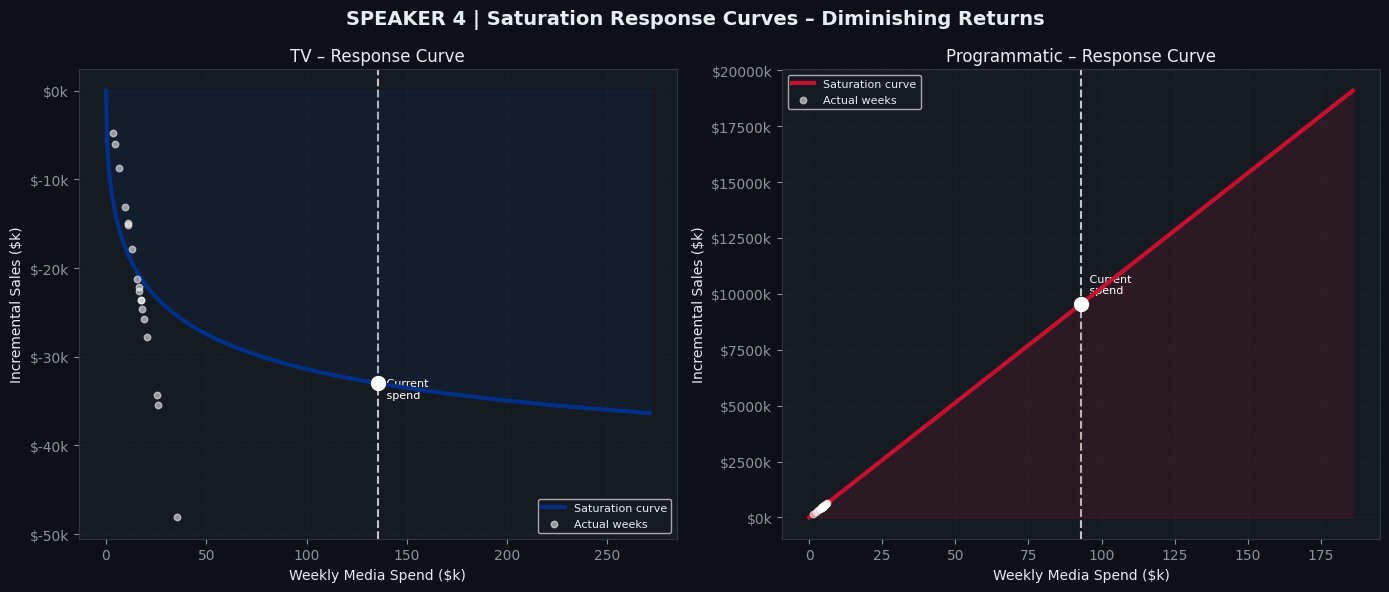

In [40]:
# Chart S4-1: Saturation response curves (fitted + real scatter)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("SPEAKER 4 | Saturation Response Curves – Diminishing Returns",
             fontsize=14, color=TEXT, fontweight="bold")

for ax, rng, resp, mroas, ch, color, cur_sp, sat_sp, a_, K_, b_ in [
    (axes[0], tv_range,   tv_resp,   tv_mroas,   "TV",           TV_COL,
     total_tv_spend,   tv_sat,   tv_a,   tv_K,   tv_b),
    (axes[1], prog_range, prog_resp, prog_mroas, "Programmatic", PROG_COL,
     total_prog_spend, prog_sat, prog_a, prog_K, prog_b),
]:
    # Fitted curve
    ax.plot(rng/1e3, resp/1e3, color=color, lw=3, zorder=4, label="Saturation curve")
    ax.fill_between(rng/1e3, resp/1e3, alpha=0.12, color=color, zorder=3)

    # Actual weekly scatter
    adstock_col = "tv_adstock" if ch == "TV" else "prog_adstock"
    contrib_col = "tv_contrib"  if ch == "TV" else "prog_contrib"
    mask = weekly[adstock_col] > 0
    ax.scatter(weekly.loc[mask, adstock_col]/1e3,
               weekly.loc[mask, contrib_col]/1e3,
               color="white", s=22, alpha=0.55, zorder=5, label="Actual weeks")

    # Current spend marker
    cur_r = hill(cur_sp, a_, K_, b_)
    ax.axvline(cur_sp/1e3, color="white", lw=1.5, ls="--", alpha=0.75)
    ax.scatter([cur_sp/1e3], [cur_r/1e3], color="white", s=100, zorder=6)
    ax.text(cur_sp/1e3*1.02, cur_r/1e3*1.05,
            " Current\n spend", color="white", fontsize=8)

    # Saturation marker (gold)
    if sat_sp:
        sat_r = hill(sat_sp, a_, K_, b_)
        ax.axvline(sat_sp/1e3, color=ACC_COL, lw=1.5, ls=":")
        ax.scatter([sat_sp/1e3], [sat_r/1e3], color=ACC_COL, s=100, zorder=6)
        ax.text(sat_sp/1e3*1.02, sat_r/1e3*0.93,
                f" Sat. ${sat_sp/1e3:.0f}k", color=ACC_COL, fontsize=8)

        # Shade wasted zone if current spend > saturation
        if cur_sp > sat_sp:
            w_mask = (rng >= sat_sp) & (rng <= cur_sp)
            ax.fill_between(rng[w_mask]/1e3, resp[w_mask]/1e3,
                            alpha=0.28, color="#EF4444", label="≈Wasted spend")

    ax.set_title(f"{ch} – Response Curve", color=TEXT)
    ax.set_xlabel("Weekly Media Spend ($k)")
    ax.set_ylabel("Incremental Sales ($k)")
    ax.legend(fontsize=8); ax.grid(True)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:.0f}k"))

plt.tight_layout()


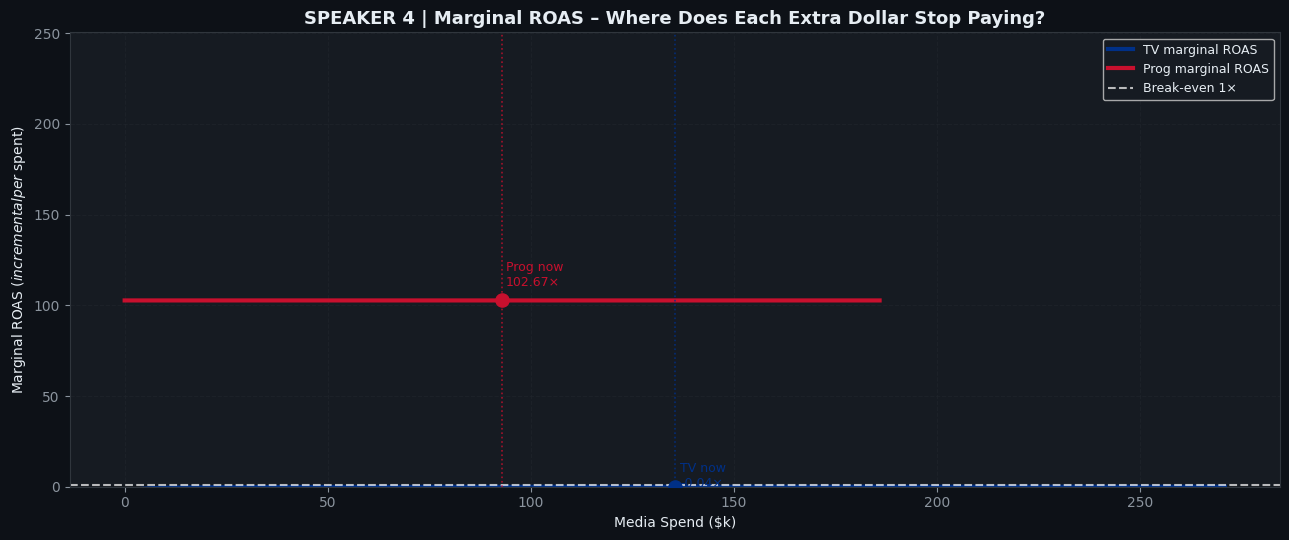

In [41]:
# Chart S4-2: Marginal ROAS

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.set_title(
    "SPEAKER 4 | Marginal ROAS – Where Does Each Extra Dollar Stop Paying?",
    fontsize=13, color=TEXT, fontweight="bold")

ax.plot(tv_range/1e3,   tv_mroas,   color=TV_COL,   lw=3, label="TV marginal ROAS")
ax.plot(prog_range/1e3, prog_mroas, color=PROG_COL, lw=3, label="Prog marginal ROAS")
ax.axhline(1.0, color="white", lw=1.5, ls="--", alpha=0.7, label="Break-even 1×")

# Current spend dots
ax.axvline(total_tv_spend/1e3,   color=TV_COL,   lw=1.2, ls=":", alpha=0.8)
ax.axvline(total_prog_spend/1e3, color=PROG_COL, lw=1.2, ls=":", alpha=0.8)
ax.scatter([total_tv_spend/1e3],   [cur_tv_m],   color=TV_COL,   s=90, zorder=5)
ax.scatter([total_prog_spend/1e3], [cur_prog_m], color=PROG_COL, s=90, zorder=5)
ax.text(total_tv_spend/1e3*1.01,   cur_tv_m*1.08,
        f"TV now\n{cur_tv_m:.2f}×",   color=TV_COL,   fontsize=9)
ax.text(total_prog_spend/1e3*1.01, cur_prog_m*1.08,
        f"Prog now\n{cur_prog_m:.2f}×", color=PROG_COL, fontsize=9)

# Shade TV diminishing zone
if tv_sat:
    dm = tv_range >= tv_sat
    ax.fill_between(tv_range[dm]/1e3, tv_mroas[dm],
                    alpha=0.10, color=TV_COL, label="TV: wasted spend zone")

ax.set_xlabel("Media Spend ($k)")
ax.set_ylabel("Marginal ROAS ($ incremental per $ spent)")
ax.legend(fontsize=9); ax.grid(True); ax.set_ylim(bottom=0)

plt.tight_layout()


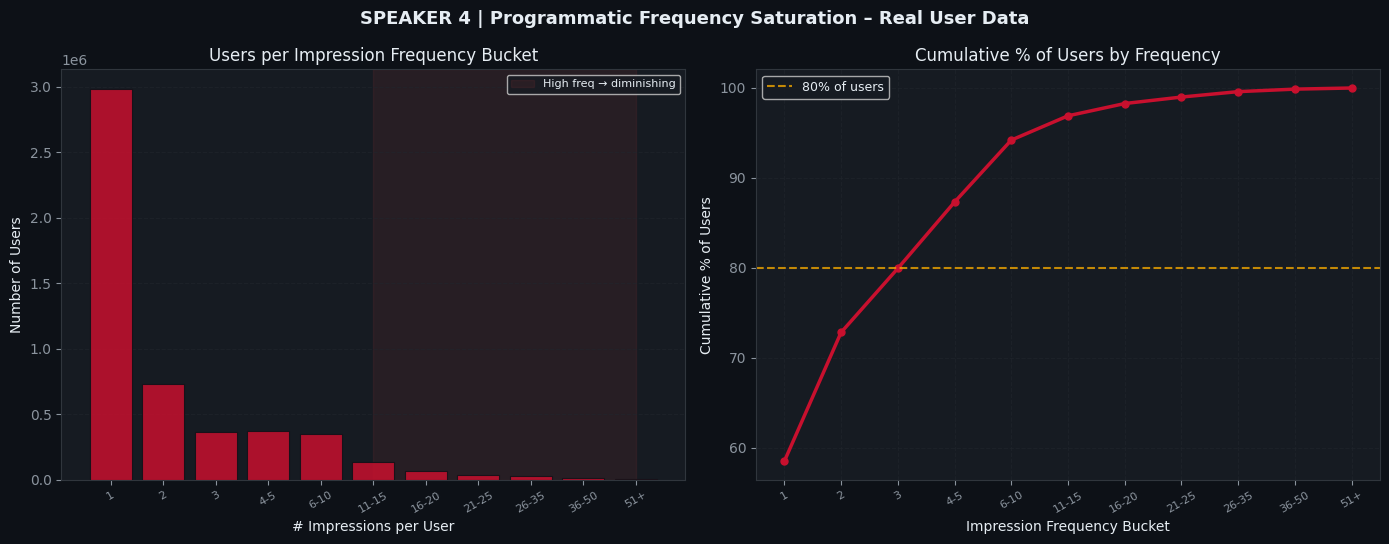

In [42]:
# Chart S4-3: Frequency distribution (real user data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle("SPEAKER 4 | Programmatic Frequency Saturation – Real User Data",
             fontsize=13, color=TEXT, fontweight="bold")

ax = axes[0]
x_f = range(len(freq_dist))
ax.bar(x_f, freq_dist["users"], color=PROG_COL, alpha=0.85, zorder=3,
       edgecolor=DARK_BG, linewidth=0.8)
ax.set_xticks(list(x_f))
ax.set_xticklabels(freq_dist["bucket"].tolist(), rotation=30, fontsize=8)
ax.set_title("Users per Impression Frequency Bucket", color=TEXT)
ax.set_xlabel("# Impressions per User")
ax.set_ylabel("Number of Users")
ax.grid(axis="y", zorder=0)
# Annotate saturation region (high freq = diminishing)
if len(freq_dist) > 4:
    ax.axvspan(5, len(freq_dist)-1, alpha=0.08, color="#EF4444",
               label="High freq → diminishing")
    ax.legend(fontsize=8)

ax = axes[1]
cum_users = freq_dist["users"].cumsum()
cum_pct   = cum_users / cum_users.iloc[-1] * 100
ax.plot(list(x_f), cum_pct, color=PROG_COL, lw=2.5, marker="o", ms=5)
ax.axhline(80, color=ACC_COL, lw=1.5, ls="--", alpha=0.8, label="80% of users")
ax.set_xticks(list(x_f))
ax.set_xticklabels(freq_dist["bucket"].tolist(), rotation=30, fontsize=8)
ax.set_title("Cumulative % of Users by Frequency", color=TEXT)
ax.set_xlabel("Impression Frequency Bucket")
ax.set_ylabel("Cumulative % of Users")
ax.legend(fontsize=9); ax.grid(True)

plt.tight_layout()



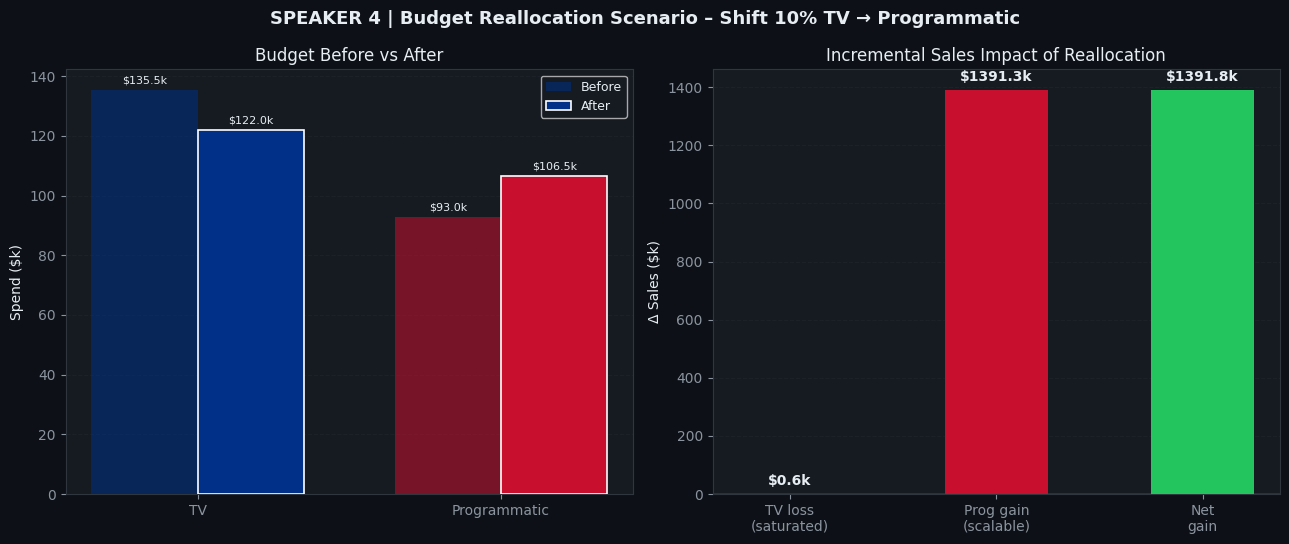

In [43]:
# Chart S4-4: Budget reallocation scenario

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle(
    f"SPEAKER 4 | Budget Reallocation Scenario – Shift {int(shift*100)}% TV → Programmatic",
    fontsize=13, color=TEXT, fontweight="bold")

x_pos = np.arange(2)
w     = 0.35
before_vals = [total_tv_spend/1e3, total_prog_spend/1e3]
after_vals  = [new_tv_spend/1e3,   new_pg_spend/1e3]

ax = axes[0]
b1 = ax.bar(x_pos-w/2, before_vals, w, color=[TV_COL,PROG_COL], alpha=0.55,
            label="Before", zorder=3)
b2 = ax.bar(x_pos+w/2, after_vals,  w, color=[TV_COL,PROG_COL], alpha=1.00,
            label="After", zorder=3, edgecolor="white", linewidth=1.2)
ax.bar_label(b1, fmt="$%.1fk", padding=3, color=TEXT, fontsize=8)
ax.bar_label(b2, fmt="$%.1fk", padding=3, color=TEXT, fontsize=8)
ax.set_xticks(x_pos); ax.set_xticklabels(["TV", "Programmatic"])
ax.set_title("Budget Before vs After", color=TEXT)
ax.set_ylabel("Spend ($k)"); ax.legend(fontsize=9); ax.grid(axis="y", zorder=0)

ax = axes[1]
bars_v = [delta_tv/1e3, delta_prog/1e3, net_gain/1e3]
bars_l = ["TV loss\n(saturated)", "Prog gain\n(scalable)", "Net\ngain"]
bars_c = [TV_COL, PROG_COL, GREEN if net_gain > 0 else "#EF4444"]
b = ax.bar(bars_l, bars_v, color=bars_c, width=0.5, zorder=3)
ax.axhline(0, color="white", lw=1, alpha=0.5)
ax.bar_label(b, fmt="$%.1fk", padding=4, color=TEXT, fontsize=10, fontweight="bold")
ax.set_title("Incremental Sales Impact of Reallocation", color=TEXT)
ax.set_ylabel("Δ Sales ($k)"); ax.grid(axis="y", zorder=0)

plt.tight_layout()


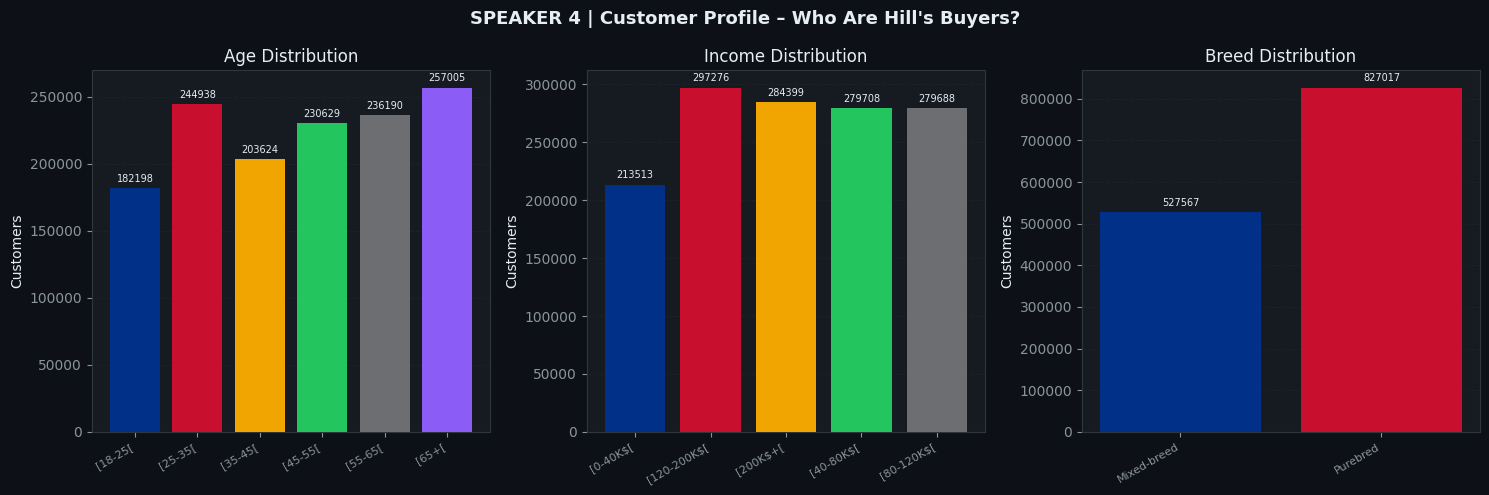

In [44]:
# Chart S4-5: Socio-demo breakdown (bonus insight)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("SPEAKER 4 | Customer Profile – Who Are Hill's Buyers?",
             fontsize=13, color=TEXT, fontweight="bold")

for ax, col, title, cmap in [
    (axes[0], "age",    "Age Distribution",    [TV_COL, PROG_COL, ACC_COL, GREEN, BASE_COL, "#8B5CF6"]),
    (axes[1], "income", "Income Distribution", [TV_COL, PROG_COL, ACC_COL, GREEN, BASE_COL, "#8B5CF6"]),
    (axes[2], "breed",  "Breed Distribution",  [TV_COL, PROG_COL, ACC_COL]),
]:
    vc  = socio[col].value_counts().sort_index()
    clr = cmap[:len(vc)]
    bars = ax.bar(range(len(vc)), vc.values, color=clr, zorder=3)
    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels(vc.index.tolist(), rotation=30, ha="right", fontsize=8)
    ax.set_title(title, color=TEXT)
    ax.set_ylabel("Customers")
    ax.grid(axis="y", zorder=0)
    ax.bar_label(bars, fmt="%d", padding=3, color=TEXT, fontsize=7)

plt.tight_layout()



In [45]:
#  FINAL SUMMARY

print("\n" + "=" * 65)
print("KEY NUMBERS FOR SLIDES")
print("=" * 65)
print(f"  Total sales          : ${total_sales:>14,.2f}")
print(f"  Avg basket size      : ${avg_basket:>14,.2f}")
print(f"  Total buyers         : {n_buyers:>14,}")
print()
print(f"  TV   spend           : ${total_tv_spend:>14,.2f}")
print(f"  Prog spend           : ${total_prog_spend:>14,.2f}")
print()
print(f"  TV   ROAS            : {roas_tv:>14.2f}×")
print(f"  Prog ROAS            : {roas_prog:>14.2f}×")
print()
print(f"  TV   sat. point      : "
      + (f"${tv_sat:>12,.0f}" if tv_sat else "   beyond range"))
print(f"  Prog sat. point      : "
      + (f"${prog_sat:>12,.0f}" if prog_sat else "   beyond range"))
print()
print(f"  TV   current mROAS   : {cur_tv_m:>14.3f}×")
print(f"  Prog current mROAS   : {cur_prog_m:>14.3f}×")
print()
print(f"  Shift 10% TV→Prog    : net sales Δ = ${net_gain:,.2f}  "
      f"({net_pct:+.2f}% of total)")
print()
print("  9 charts saved in ./outputs/")
print("=" * 65)


KEY NUMBERS FOR SLIDES
  Total sales          : $ 62,427,949.18
  Avg basket size      : $         43.37
  Total buyers         :        502,026

  TV   spend           : $    135,510.61
  Prog spend           : $     92,973.13

  TV   ROAS            :          -2.88×
  Prog ROAS            :         127.34×

  TV   sat. point      :    beyond range
  Prog sat. point      :    beyond range

  TV   current mROAS   :         -0.038×
  Prog current mROAS   :        102.669×

  Shift 10% TV→Prog    : net sales Δ = $1,391,816.73  (+2.23% of total)

  9 charts saved in ./outputs/
